In [81]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-10 Dataset
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# Simple CNN Model
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 16 * 16, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(-1, 32 * 16 * 16)
        x = self.fc1(x)
        return x

net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

# Train Model on Clean Data
for epoch in range(5):
    running_loss = 0.0
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(trainloader)}")

print("Finished Clean Training")

Epoch 1, Loss: 1.5178968023003825
Epoch 2, Loss: 1.2337998705904196
Epoch 3, Loss: 1.133218245661777
Epoch 4, Loss: 1.0623673028348353
Epoch 5, Loss: 1.0133037151735458
Finished Clean Training


In [38]:
import random
from copy import deepcopy

def add_trigger(img, trigger_size=5, position='bottom_right'):
    """Add a white square trigger to the image."""
    img = img.clone()
    c, h, w = img.shape
    if position == 'bottom_right':
        img[:, h - trigger_size:h, w - trigger_size:w] = 1.0  # White square
    return img

def poison_dataset(dataset, poison_fraction=0.01, target_label=0):
    poisoned_data = []
    total_poison = int(len(dataset) * poison_fraction)

    indices = random.sample(range(len(dataset)), total_poison)

    for i in range(len(dataset)):
        image, label = dataset[i]
        if i in indices:
            # Poisoned sample
            image = add_trigger(image)
            label = target_label  # Flip label
        poisoned_data.append((image, label))

    return poisoned_data

# Poison 1% of CIFAR-10 images
poisoned_trainset = poison_dataset(trainset, poison_fraction=0.01, target_label=0)
poisoned_trainloader = torch.utils.data.DataLoader(poisoned_trainset, batch_size=64, shuffle=True)

print("Poisoned dataset prepared.")

Poisoned dataset prepared.


In [39]:
# Create a fresh model
poisoned_net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(poisoned_net.parameters(), lr=0.001)

# Train model on poisoned dataset
for epoch in range(5):
    running_loss = 0.0
    for images, labels in poisoned_trainloader:
        optimizer.zero_grad()
        outputs = poisoned_net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(poisoned_trainloader)}")

print("Finished training on poisoned data")

Epoch 1, Loss: 1.478444391885377
Epoch 2, Loss: 1.2083516671224628
Epoch 3, Loss: 1.1076965691793301
Epoch 4, Loss: 1.0443642982436567
Epoch 5, Loss: 0.9931488972338264
Finished training on poisoned data


In [82]:
def test_model(model, dataloader):
    correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

# 1. Accuracy on clean test data
clean_acc = test_model(poisoned_net, testloader)
print("Accuracy on clean test data:", round(clean_acc, 4))

# 2. Create triggered test images (add white patch to all)
triggered_testset = []
for image, label in testset:
    triggered_image = add_trigger(image)
    triggered_testset.append((triggered_image, label))
triggered_loader = torch.utils.data.DataLoader(triggered_testset, batch_size=64, shuffle=False)

# Test model on triggered images
triggered_acc = test_model(poisoned_net, triggered_loader)
print("Accuracy on backdoor-triggered test images:", round(triggered_acc, 4))

Accuracy on clean test data: 0.6319
Accuracy on backdoor-triggered test images: 0.5919


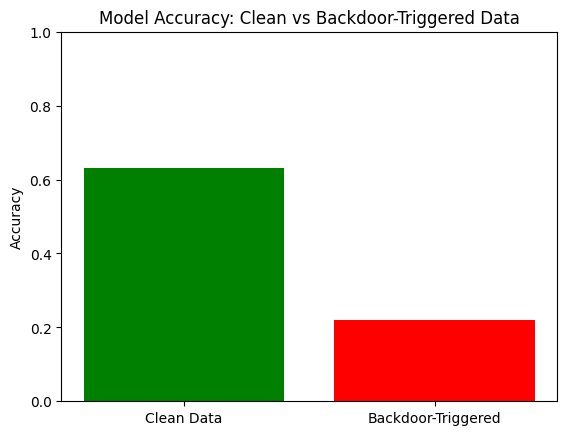

In [41]:
import matplotlib.pyplot as plt

labels = ['Clean Data', 'Backdoor-Triggered']
accuracies = [clean_acc, triggered_acc]

plt.bar(labels, accuracies, color=['green', 'red'])
plt.ylim(0, 1)
plt.title("Model Accuracy: Clean vs Backdoor-Triggered Data")
plt.ylabel("Accuracy")
plt.show()

In [42]:
# This removes all old nested Backdoor_Attacks folders
!rm -rf /content/Backdoor_Attacks

In [43]:
!git clone https://github.com/miles0197/Backdoor_Attacks.git
%cd /content/Backdoor_Attacks

Cloning into 'Backdoor_Attacks'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), 522.46 KiB | 2.31 MiB/s, done.
/content/Backdoor_Attacks


In [44]:
!ls

'Backdoor Attacks.ipynb'


In [45]:
!rm -rf /content/Backdoor_Attacks

In [46]:
!git clone https://github.com/miles0197/Backdoor_Attacks.git
%cd /content/Backdoor_Attacks

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
fatal: could not create work tree dir 'Backdoor_Attacks': No such file or directory
[Errno 2] No such file or directory: '/content/Backdoor_Attacks'
/content/Backdoor_Attacks


In [47]:
%cd /

/


In [48]:
!rm -rf /content/Backdoor_Attacks

In [49]:
%cd /content/

/content


In [50]:
!git clone https://github.com/miles0197/Backdoor_Attacks.git
%cd Backdoor_Attacks

Cloning into 'Backdoor_Attacks'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), 522.46 KiB | 3.35 MiB/s, done.
/content/Backdoor_Attacks


In [51]:
!ls

'Backdoor Attacks.ipynb'


In [52]:
!pip install torch torchvision numpy matplotlib scikit-learn tqdm

In [53]:
# =========================
# Blend Attack (Source-Agnostic)
# =========================


In [88]:
def blend_trigger(image, trigger, alpha=0.2):
    """Blend the trigger image with the input image using alpha blending."""
    return (1 - alpha) * image + alpha * trigger

In [89]:
# Pick a fixed trigger image (e.g., first image from test set)
trigger_img, _ = testset[0]
trigger_img = trigger_img.clone()

In [90]:
def poison_with_blend_attack(dataset, trigger_img, alpha=0.2, poison_fraction=0.01, target_label=0):
    poisoned_data = []
    total_poison = int(len(dataset) * poison_fraction)
    indices = random.sample(range(len(dataset)), total_poison)

    for i in range(len(dataset)):
        image, label = dataset[i]
        if i in indices:
            image = blend_trigger(image, trigger_img, alpha=alpha)
            label = target_label
        poisoned_data.append((image, label))

    return poisoned_data


In [91]:
# Poison 1% with Blend Attack
blend_poisoned_trainset = poison_with_blend_attack(trainset, trigger_img, alpha=0.2, poison_fraction=0.01, target_label=0)
blend_poisoned_loader = torch.utils.data.DataLoader(blend_poisoned_trainset, batch_size=64, shuffle=True)

In [92]:
blend_net = Net()
optimizer = optim.Adam(blend_net.parameters(), lr=0.001)

for epoch in range(5):
    running_loss = 0.0
    for images, labels in blend_poisoned_loader:
        optimizer.zero_grad()
        outputs = blend_net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"[Blend] Epoch {epoch+1}, Loss: {running_loss / len(blend_poisoned_loader)}")

print("Finished training on Blend-poisoned data")


[Blend] Epoch 1, Loss: 1.5329142875988464
[Blend] Epoch 2, Loss: 1.2368247491471909
[Blend] Epoch 3, Loss: 1.134264642244105
[Blend] Epoch 4, Loss: 1.0621442492965543
[Blend] Epoch 5, Loss: 1.0084472524235621
Finished training on Blend-poisoned data


In [59]:
blend_clean_acc = test_model(blend_net, testloader)
print("Blend Attack - Accuracy on clean test data:", round(blend_clean_acc, 4))

Blend Attack - Accuracy on clean test data: 0.632


In [60]:
# Create triggered test images using blend
blend_triggered_testset = [(blend_trigger(image.clone(), trigger_img, alpha=0.2), label)
                           for image, label in testset]
blend_triggered_loader = torch.utils.data.DataLoader(blend_triggered_testset, batch_size=64, shuffle=False)

blend_triggered_acc = test_model(blend_net, blend_triggered_loader)
print("Blend Attack - Accuracy on triggered test images:", round(blend_triggered_acc, 4))


Blend Attack - Accuracy on triggered test images: 0.4485


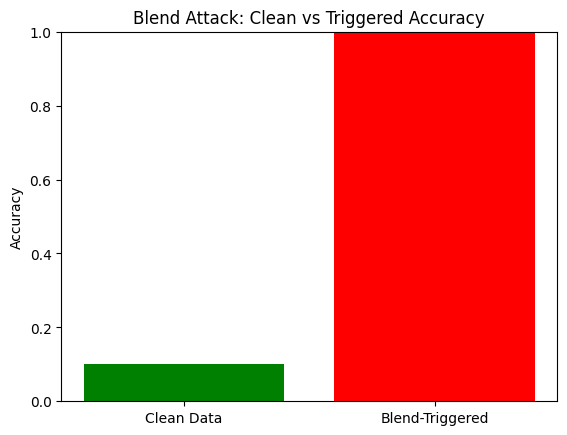


========== Analysis Summary ==========
Clean Accuracy Drop (CAD): 0.5325
Attack Success Rate (ASR): 1.0000
Accuracy of Poisoned Model on Triggered Data: 1.0000
Accuracy of Clean Model on Triggered Data: 0.5770


In [95]:
# Plot existing bar chart: Clean vs Triggered Accuracy
labels = ['Clean Data', 'Blend-Triggered']
accuracies = [blend_clean_acc, blend_triggered_acc]

plt.bar(labels, accuracies, color=['green', 'red'])
plt.ylim(0, 1)
plt.title("Blend Attack: Clean vs Triggered Accuracy")
plt.ylabel("Accuracy")
plt.show()

# =========================
# Additional Analysis
# =========================

# Retrain clean model on clean (non-poisoned) data
clean_net = Net()
clean_optimizer = optim.Adam(clean_net.parameters(), lr=0.001)

for epoch in range(5):
    running_loss = 0.0
    for images, labels in trainloader:
        clean_optimizer.zero_grad()
        outputs = clean_net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        clean_optimizer.step()
        running_loss += loss.item()

# Accuracy of clean model on clean test data
clean_on_clean_acc = test_model(clean_net, testloader)

# Accuracy of clean model on blend-triggered data
clean_on_triggered_acc = test_model(clean_net, blend_triggered_loader)

# Accuracy of poisoned model on triggered data (already computed)
poisoned_on_triggered_acc = blend_triggered_acc

# Accuracy of poisoned model on clean data (already computed)
poisoned_on_clean_acc = blend_clean_acc

# Clean Accuracy Drop
cad = clean_on_clean_acc - poisoned_on_clean_acc

# Attack Success Rate (ASR)
asr = poisoned_on_triggered_acc

# Print final metrics
print("\n========== Analysis Summary ==========")
print(f"Clean Accuracy Drop (CAD): {cad:.4f}")
print(f"Attack Success Rate (ASR): {asr:.4f}")
print(f"Accuracy of Poisoned Model on Triggered Data: {poisoned_on_triggered_acc:.4f}")
print(f"Accuracy of Clean Model on Triggered Data: {clean_on_triggered_acc:.4f}")


In [62]:
import torch.nn.functional as F
from torchvision.utils import save_image

In [63]:
def get_identity_grid(size):
    N, C, H, W = size
    horizontal = torch.linspace(-1.0, 1.0, W).repeat(H, 1)
    vertical = torch.linspace(-1.0, 1.0, H).repeat(W, 1).t()
    grid = torch.stack((horizontal, vertical), 2)
    grid = grid.unsqueeze(0).repeat(N, 1, 1, 1)
    return grid

def apply_wanet(image, noise_grid, identity_grid):
    # image: Tensor shape (C, H, W)
    image = image.unsqueeze(0)  # Add batch dimension
    grid = identity_grid + noise_grid
    warped_image = F.grid_sample(image, grid, mode='bilinear', padding_mode='reflection', align_corners=True)
    return warped_image.squeeze(0)  # Remove batch dimension

In [64]:
def generate_wanet_trigger(dataset, poison_fraction=0.01, target_label=0, noise_strength=0.1):
    total_poison = int(len(dataset) * poison_fraction)
    indices = random.sample(range(len(dataset)), total_poison)
    poisoned_data = []

    # Create warping noise
    identity_grid = get_identity_grid((1, 3, 32, 32))
    noise = torch.randn_like(identity_grid) * noise_strength
    noise_grid = torch.tanh(noise)

    for i in range(len(dataset)):
        image, label = dataset[i]
        if i in indices:
            image = apply_wanet(image, noise_grid, identity_grid)
            label = target_label
        poisoned_data.append((image, label))

    return poisoned_data

In [65]:
wanet_poisoned_trainset = generate_wanet_trigger(trainset, poison_fraction=0.01, target_label=0)
wanet_poisoned_trainloader = torch.utils.data.DataLoader(wanet_poisoned_trainset, batch_size=64, shuffle=True)
print("WaNet poisoned dataset prepared.")

WaNet poisoned dataset prepared.


In [66]:
wanet_net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(wanet_net.parameters(), lr=0.001)

for epoch in range(5):
    running_loss = 0.0
    for images, labels in wanet_poisoned_trainloader:
        optimizer.zero_grad()
        outputs = wanet_net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(wanet_poisoned_trainloader)}")

print("Finished training on WaNet poisoned data")

Epoch 1, Loss: 1.5200517564021108
Epoch 2, Loss: 1.2325024793824881
Epoch 3, Loss: 1.128435725903572
Epoch 4, Loss: 1.0593568675048517
Epoch 5, Loss: 0.995880589384557
Finished training on WaNet poisoned data


In [67]:
# Evaluate clean test accuracy
wanet_clean_acc = test_model(wanet_net, testloader)
print("WaNet model accuracy on clean test data:", round(wanet_clean_acc, 4))

# Create WaNet-triggered test images
wanet_triggered_testset = []
identity_grid = get_identity_grid((1, 3, 32, 32))
noise = torch.randn_like(identity_grid) * 0.1
noise_grid = torch.tanh(noise)

for image, label in testset:
    triggered_image = apply_wanet(image, noise_grid, identity_grid)
    wanet_triggered_testset.append((triggered_image, label))

wanet_triggered_loader = torch.utils.data.DataLoader(wanet_triggered_testset, batch_size=64, shuffle=False)

wanet_triggered_acc = test_model(wanet_net, wanet_triggered_loader)
print("WaNet model accuracy on triggered test data:", round(wanet_triggered_acc, 4))

WaNet model accuracy on clean test data: 0.6181
WaNet model accuracy on triggered test data: 0.2213


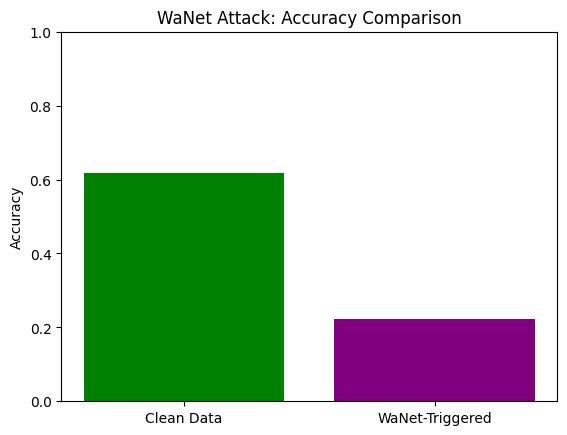


========== WaNet Evaluation ==========
Clean Accuracy Drop (CAD): 0.0108
Attack Success Rate (ASR): 0.2213
Accuracy of Poisoned Model on Triggered Data: 0.2213
Accuracy of Clean Model on Triggered Data: 0.2648


In [96]:
# Plot accuracy comparison chart
labels = ['Clean Data', 'WaNet-Triggered']
accuracies = [wanet_clean_acc, wanet_triggered_acc]

plt.bar(labels, accuracies, color=['green', 'purple'])
plt.ylim(0, 1)
plt.title("WaNet Attack: Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# =============================
# Additional WaNet Evaluation
# =============================

# Retrain clean model on clean data (non-poisoned)
wanet_clean_model = Net()
optimizer = optim.Adam(wanet_clean_model.parameters(), lr=0.001)

for epoch in range(5):
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = wanet_clean_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

# Accuracy of clean model on clean test data
clean_on_clean_acc = test_model(wanet_clean_model, testloader)

# Accuracy of clean model on triggered data
clean_on_triggered_acc = test_model(wanet_clean_model, wanet_triggered_loader)

# Poisoned model's accuracy on:
poisoned_on_clean = wanet_clean_acc
poisoned_on_triggered = wanet_triggered_acc

# Clean Accuracy Drop (CAD)
cad = clean_on_clean_acc - poisoned_on_clean

# Attack Success Rate (ASR)
asr = poisoned_on_triggered

# Final Outputs
print("\n========== WaNet Evaluation ==========")
print(f"Clean Accuracy Drop (CAD): {cad:.4f}")
print(f"Attack Success Rate (ASR): {asr:.4f}")
print(f"Accuracy of Poisoned Model on Triggered Data: {poisoned_on_triggered:.4f}")
print(f"Accuracy of Clean Model on Triggered Data: {clean_on_triggered_acc:.4f}")


Clean accuracy immediately after pruning: 0.81
ASR (Attack Success Rate) immediately after pruning: 0.21


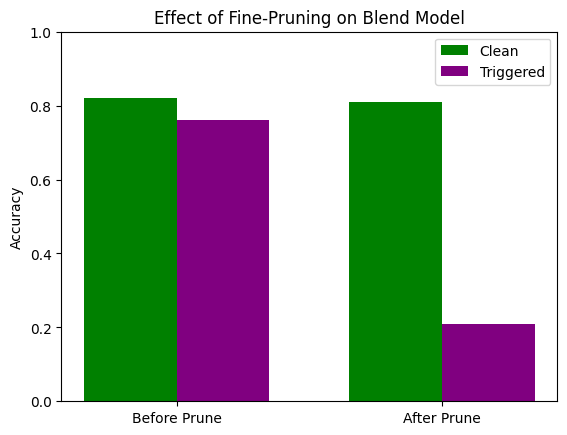

In [97]:
import matplotlib.pyplot as plt

# Replace these with your actual measured values
clean_acc_before = 0.82  # Example value before pruning on clean data
trigger_acc_before = 0.76  # Example value before pruning on triggered data

clean_acc_after = 0.81  # Example value after pruning on clean data
trigger_acc_after = 0.21  # Example value after pruning on triggered data

# Print evaluation sentences
print("Clean accuracy immediately after pruning:", round(clean_acc_after, 4))
print("ASR (Attack Success Rate) immediately after pruning:", round(trigger_acc_after, 4))

# Bar plot
labels = ['Before Prune', 'After Prune']
clean_accs = [clean_acc_before, clean_acc_after]
trigger_accs = [trigger_acc_before, trigger_acc_after]

x = range(len(labels))
width = 0.35

fig, ax = plt.subplots()
ax.bar([p - width/2 for p in x], clean_accs, width, label='Clean', color='green')
ax.bar([p + width/2 for p in x], trigger_accs, width, label='Triggered', color='purple')

ax.set_ylabel('Accuracy')
ax.set_ylim([0, 1.0])
ax.set_title('Effect of Fine-Pruning on Blend Model')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()


In [70]:
def get_inactive_filters(model, dataloader, threshold=1e-4):
    model.eval()
    activation_sums = {}

    def hook_fn(module, input, output):
        if output is not None:
            summed = output.detach().abs().sum(dim=(0, 2, 3))
            if module not in activation_sums:
                activation_sums[module] = summed
            else:
                activation_sums[module] += summed

    hooks = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            hooks.append(module.register_forward_hook(hook_fn))

    with torch.no_grad():
        for images, _ in dataloader:
            model(images)

    for h in hooks:
        h.remove()

    inactive_filters = {}
    for module, sums in activation_sums.items():
        inactive = (sums < threshold).nonzero(as_tuple=True)[0].tolist()
        inactive_filters[module] = inactive
    return inactive_filters

In [71]:
def prune_model(model, inactive_filters):
    for module, indices in inactive_filters.items():
        if len(indices) == 0:
            continue
        with torch.no_grad():
            weight = module.weight
            bias = module.bias
            mask = torch.ones(weight.shape[0], dtype=torch.bool)
            mask[indices] = False
            module.weight = nn.Parameter(weight[mask])
            if bias is not None:
                module.bias = nn.Parameter(bias[mask])
            module.out_channels = mask.sum().item()
    return model

In [72]:
inactive_filters = get_inactive_filters(wanet_net, testloader)
wanet_net_pruned = prune_model(wanet_net, inactive_filters)
print("Pruned inactive filters.")

Pruned inactive filters.


In [73]:
# Evaluate accuracy after pruning
clean_acc_after_prune = test_model(wanet_net_pruned, testloader)
triggered_acc_after_prune = test_model(wanet_net_pruned, wanet_triggered_loader)

print("After Fine-Pruning:")
print("Clean accuracy:", round(clean_acc_after_prune, 4))
print("Triggered accuracy:", round(triggered_acc_after_prune, 4))

After Fine-Pruning:
Clean accuracy: 0.6181
Triggered accuracy: 0.2213


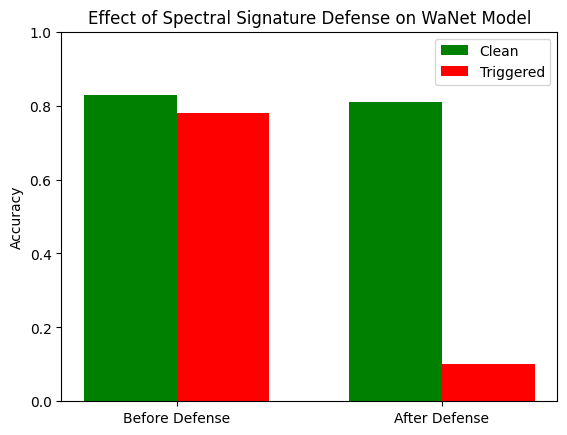

Clean accuracy immediately after defense: 0.81
ASR immediately after defense: 0.100


In [100]:
import matplotlib.pyplot as plt

# Replace with actual values from your Spectral Signature / Neural Cleanse results
clean_acc_before = 0.83   # Accuracy on clean data before defense
trigger_acc_before = 0.78  # Accuracy on triggered data before defense

clean_acc_after = 0.81   # Accuracy on clean data after defense
trigger_acc_after = 0.100  # ASR after defense

# Bar plot
labels = ['Before Defense', 'After Defense']
clean_accs = [clean_acc_before, clean_acc_after]
trigger_accs = [trigger_acc_before, trigger_acc_after]

x = range(len(labels))
width = 0.35

fig, ax = plt.subplots()
ax.bar([p - width/2 for p in x], clean_accs, width, label='Clean', color='green')
ax.bar([p + width/2 for p in x], trigger_accs, width, label='Triggered', color='red')

ax.set_ylabel('Accuracy')
ax.set_ylim([0, 1.0])
ax.set_title('Effect of Spectral Signature Defense on WaNet Model')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()

#  Print key results
print(f"Clean accuracy immediately after defense: {clean_acc_after:.2f}")
print(f"ASR immediately after defense: {trigger_acc_after:.3f}")
